In [23]:
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

dataset = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean-with-fd-clamped",
)



In [31]:

subject = "04"
run = 5
state = "2"
df = dataset.events

run_df = df[(df["subject"] == subject) & (df["run"] == run)]
state_mask = run_df[state].reset_index(drop=True).to_numpy()
state_mask.sum()


15

  Skipping 15 run 3 (no EOG data)
  Skipping 16 run 1 (no EOG data)
  Skipping 16 run 2 (no EOG data)
  Skipping 16 run 3 (no EOG data)
  Skipping 16 run 4 (no EOG data)
  Skipping 16 run 5 (no EOG data)
  Skipping 18 run 1 (no EOG data)
  Skipping 18 run 2 (no EOG data)
  Skipping 18 run 3 (no EOG data)
  Skipping 18 run 4 (no EOG data)
  Skipping 18 run 5 (no EOG data)

Per-run correlations (146 runs):
          mean    std  count
subject                     
03       0.251  0.065      8
04       0.427  0.054      6
05       0.233  0.104      6
06       0.277  0.088      4
08       0.239  0.140      7
10       0.148  0.098      6
11       0.219  0.024      2
13       0.283  0.187      4
14       0.195  0.055      7
15       0.239  0.064      5
16       0.295    NaN      1
17       0.144  0.088      6
19       0.145  0.036      5
20       0.183  0.093      4
22       0.172  0.063      8
23       0.242  0.112      5
24       0.106  0.033      6
25       0.270  0.133      6
26       0.2

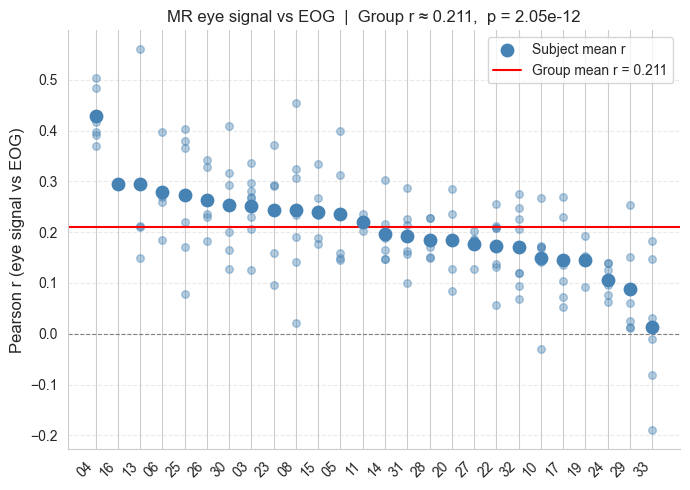

In [11]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Collect per-run correlations ──────────────────────────────────────────

records = []

for subject, run, run_df in dataset.iter_run_events():
    eye_signal, _ = dataset.load_eye_move(subject, run, desc_add="clean-with-fd-clamped")

    eog_rows = run_df["eog"]
    if eog_rows.isna().any():
        print(f"  Skipping {subject} run {run} (no EOG data)")
        continue

    eog_signal = eog_rows.values.astype(float)

    n = min(len(eye_signal), len(eog_signal))
    if n < 10:
        print(f"  Skipping {subject} run {run} (too few samples: {n})")
        continue

    r, p = stats.pearsonr(eye_signal, eog_signal)
    if r == np.nan:
        continue
    records.append(dict(
        subject=subject,
        run=run,
        r=r, p=p, n=n,
        mean_eye=np.mean(np.abs(eye_signal[:n])),
        mean_eog=np.mean(np.abs(eog_signal[:n])),
    ))

run_df = pd.DataFrame(records)
print(f"\nPer-run correlations ({len(run_df)} runs):")
print(run_df.groupby("subject")["r"].agg(["mean", "std", "count"]).round(3))

# ── 2. Per-subject average r (Fisher z then back) ────────────────────────────

def fisher_mean(r_values):
    z = np.arctanh(np.clip(r_values, -0.9999, 0.9999))
    return np.tanh(np.mean(z))

subj_df = (
    run_df.groupby("subject")["r"]
    .agg(fisher_mean_r=lambda x: fisher_mean(x.values), n_runs="count")
    .reset_index()
)

print(f"\nPer-subject mean r (Fisher-averaged):")
print(subj_df.round(3))

# ── 3. Group-level summary ────────────────────────────────────────────────────

z_scores = np.arctanh(np.clip(subj_df["fisher_mean_r"].values, -0.9999, 0.9999))
group_r  = np.tanh(np.mean(z_scores))
se       = np.std(z_scores) / np.sqrt(len(z_scores))
ci_low   = np.tanh(np.mean(z_scores) - 1.96 * se)
ci_high  = np.tanh(np.mean(z_scores) + 1.96 * se)
t_stat, p_val = stats.ttest_1samp(z_scores, 0)

print(f"\nGroup-level MR-eye vs EOG correlation:")
print(f"  Mean r = {group_r:.3f}  95% CI [{ci_low:.3f}, {ci_high:.3f}]")
print(f"  One-sample t({len(z_scores)-1}) = {t_stat:.3f},  p = {p_val:.4f}")

# ── Plot: per-subject mean time-series r, with individual runs shown ──────────

subj_r = run_df.groupby("subject")["r"].agg(fisher_mean).reset_index()
subj_r.columns = ["subject", "mean_r"]
subj_r = subj_r.sort_values("mean_r", ascending=False).reset_index(drop=True)

p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"

fig, ax = plt.subplots(figsize=(7, 5))

# Individual run dots per subject
for i, row in subj_r.iterrows():
    runs = run_df[run_df["subject"] == row["subject"]]["r"].values
    ax.scatter([i] * len(runs), runs, color="steelblue", alpha=0.4, s=30, zorder=2)

# Subject mean
ax.scatter(range(len(subj_r)), subj_r["mean_r"], color="steelblue", s=80, zorder=3, label="Subject mean r")

# Reference lines
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.axhline(group_r, color="red", lw=1.5, ls="-", label=f"Group mean r = {group_r:.3f}")

ax.set_xticks(range(len(subj_r)))
ax.set_xticklabels(subj_r["subject"].str.replace("sub-", ""), rotation=45, ha="right")
ax.set_ylabel("Pearson r (eye signal vs EOG)", fontsize=12)
ax.set_title(f"MR eye signal vs EOG  |  Group r ≈ {group_r:.3f},  p = {p_str}", fontsize=12)
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("mreyemove_eog_r_per_subject.svg", dpi=150)
plt.show()